In [1]:
# 项目实战：房地产市场洞察与价值评估
# 1. 导入相关库
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams
# 1.1 设置中文字体
rcParams['font.sans-serif'] = ['SimHei']

In [ ]:
# 2. 导入数据
df = pd.read_csv('data/house_sales.csv')

In [ ]:
# 3. 数据概览
print(f"总记录数: {len(df)}")
print(f"字段总数: {len(df.columns)}")
df.head(5)
df.info()

总记录数: 106118
字段总数: 12
<class 'pandas.DataFrame'>
RangeIndex: 106118 entries, 0 to 106117
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   city        106118 non-null  str  
 1   address     104452 non-null  str  
 2   area        105324 non-null  str  
 3   floor       104024 non-null  str  
 4   name        105564 non-null  str  
 5   price       105564 non-null  str  
 6   province    106118 non-null  str  
 7   rooms       104036 non-null  str  
 8   toward      105240 non-null  str  
 9   unit        105564 non-null  str  
 10  year        57736 non-null   str  
 11  origin_url  105564 non-null  str  
dtypes: str(12)
memory usage: 9.7 MB


In [9]:
# 4. 数据清洗
# 4.1 删除无用的数据列
df.drop(columns='origin_url',inplace=True)

In [ ]:
# 4.2 检查是否有缺失值
df.isna().sum()
# 4.3 处理缺失值，这里直接删掉
df.dropna(inplace=True)

In [ ]:
# 4.4 检查是否有重复值
print(f"重复值数量: {df.duplicated().sum()}")
# 4.5 删除重复数据
df.drop_duplicates(inplace=True)

重复值数量: 29416


In [24]:
# 4.6 处理area字段去除单位
df['area'] = df['area'].str.replace('㎡','').astype(float)

AttributeError: Can only use .str accessor with string values, not floating

In [28]:
# 4.7 售价的数据类型转换
df['price'] = df['price'].str.replace('万','').astype(float)

In [31]:
# 4.8 将朝向字段转换为分类型
df['toward'] = df['toward'].astype('category')

In [ ]:
# 4.9 unit的数据转换为浮点型
df['unit'] = df['unit'].str.replace('元/㎡','').astype(float)

In [ ]:
# 4.10 将年份字段转换为整数类型
df['year'] = df['year'].str.replace('年建','').astype(int)

In [45]:
# 4.11 异常值的处理
# 4.11.1 房屋面积的异常处理
df = df[(df['area'] < 600) & (df['area'] > 20)]

In [49]:
# 4.11.2 房屋售价的异常处理     IQR的方法
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
low_price = Q1 - 1.5 * IQR
high_price = Q3 + 1.5 * IQR
df = df[(df['price'] > low_price) & (df['price'] < high_price)]

In [ ]:
# 5. 新数据特征的构造
# 5.1 地区district
df['district'] = df['address'].str.split('-').str[0]

,city,address,area,floor,name,price,province,rooms,toward,unit,year,district
0,合肥,龙岗-临泉东路和王岗大道交叉口东南角,90.0,中层（共18层）,圣地亚哥,128.0,安徽,3室2厅,南北向,14222.0,2013,龙岗
2,合肥,生态公园-淮海大道与大众路交口,95.0,中层（共18层）,正荣·悦都荟,132.0,安徽,3室2厅,南向,13895.0,2019,生态公园
4,合肥,撮镇-文一名门金隅裕溪路与东风大道交口,37.0,中层（共22层）,文一名门金隅,32.0,安徽,2室1厅,南北向,8649.0,2017,撮镇
6,合肥,龙岗-长江东路与和县里交口,50.0,高层（共30层）,柏庄金座,46.0,安徽,2室1厅,南向,9200.0,2019,龙岗
8,合肥,新亚汽车站-张洼路与临泉路交汇处向北100米(原红星机械,120.0,中层（共27层）,天目未来,158.0,安徽,4室2厅,南向,13167.0,2012,新亚汽车站


In [ ]:
# 5.2 楼层的类型floor_type
# 5.2.1 小括号的分割方式
df['floor_type'] = df['floor'].str.split('（').str[0].astype(object)
# 5.2.2 函数的分割方式
def fun1(str1):
    if pd.isna(str1):
        return '未知'
    elif '低' in str1:
        return '低楼层'
    elif '中' in str1:
        return '中楼层'
    elif '高' in str1:
        return '高楼层'
    else:
        return '未知'
df['floor_type2'] = df['floor'].apply(fun1).astype(object)
# 5.3 是否是直辖市is_direct
def fun2(str):
    return True if str in ['北京', '上海', '广州', '深圳'] else False
# df['city'].apply(lambda x: fun2(x))
df['is_direct'] = df['city'].apply(fun2).astype(bool)

In [ ]:
# 5.4 卧室的数量bedrooms
df['bedrooms'] = df['rooms'].str.split('室').str[0].astype(int)

In [75]:
# 5.5 客厅的数量living_rooms
df['living_rooms'] = df['rooms'].str.split('室').str[1].str.split('厅').str[0].astype(int)
df['rooms'].str.extract(r'(\d+)厅').astype(int) # 正则表达式的方法

,0
0,2
2,2
4,1
6,1
8,2
...,...
106080,2
106082,2
106084,1
106086,2


In [ ]:
# 5.6 楼龄building_age
df['building_age'] = (2026 - df['year']).astype(int)

In [81]:
# 5.7 价格的分段price_labels
df['price_labels'] = pd.cut(df['price'], bins=5, labels=['低', '中', '高', '超高', '超超高']).astype(object)

In [84]:
df['price_labels'].value_counts()

price_labels
中      11114
低       5801
高       5587
超高      2387
超超高     1246
Name: count, dtype: int64

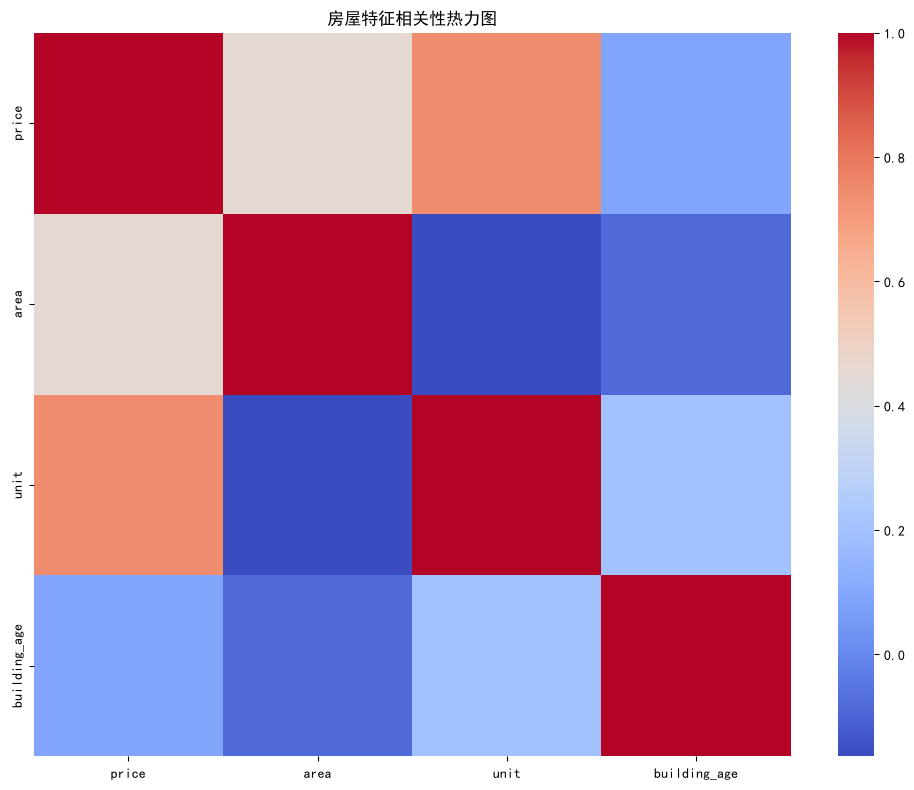

In [94]:
"""
问题编号:A1
问题:哪些变量最影响房价?面积、楼层、房间数哪个影响更大?
分析主题:特征相关性
分析目标:了解房屋各特征对房价的线性影响
分组字段:无
指标/方法:皮尔逊相关系数
"""
# 选择数据型特征
a = df[['price','area','unit','building_age']].corr()   # 计算相关系数的函数
# 对房价影响最大的几个因素的排序
a['price'].sort_values(ascending=False)[1:]
# 相关性的热力图
plt.figure(figsize=(10, 8))
sns.heatmap(a,cmap='coolwarm')
plt.title('房屋特征相关性热力图')
plt.tight_layout()

In [96]:
"""
问题编号:A2
问题:全国房价总体分布是怎样的?是否存在极端值?
分析主题:描述性统计
分析目标:概览数值型字段的分布特征
分组字段:无
指标/方法:平均数/中位数/四分位数/标准差
"""
df.describe()

,area,price,unit,year,bedrooms,living_rooms,building_age
count,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000,26135.000000
mean,103.755810,117.208370,11610.131012,2013.072240,2.714444,1.848556,12.927760
std,33.995994,60.967675,5824.245273,6.019342,0.800768,0.407353,6.019342
min,21.000000,9.000000,1000.000000,1976.000000,0.000000,0.000000,3.000000
25%,85.005000,72.000000,7587.000000,2011.000000,2.000000,2.000000,9.000000
50%,100.000000,103.000000,10312.000000,2015.000000,3.000000,2.000000,11.000000
75%,123.000000,150.000000,14184.000000,2017.000000,3.000000,2.000000,15.000000
max,470.000000,306.000000,85288.000000,2023.000000,9.000000,12.000000,50.000000


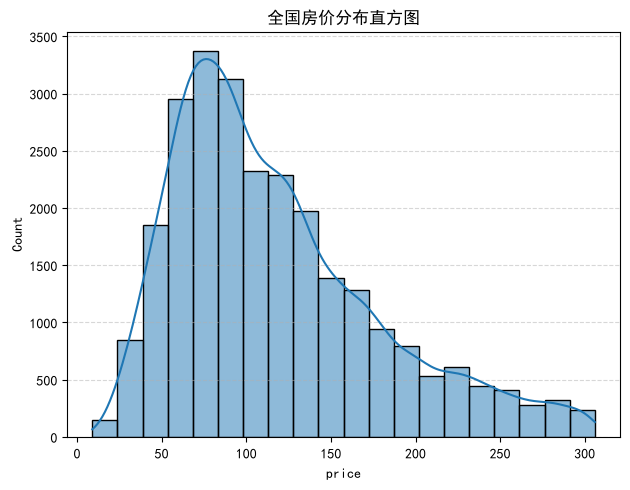

In [108]:
# 房价分布的直方图
sns.histplot(df['price'], bins=20,kde=True)
plt.tight_layout()
plt.title('全国房价分布直方图')
plt.grid(axis='y',alpha=0.5,linestyle='--')
plt.show()


In [114]:
"""
问题编号:A6
问题:南北向是否真比单一朝向贵?贵多少?
分析主题:朝向溢价
分析目标:评估不同朝向的价格差异
分组字段:toward
指标/方法:方差分析/多重比较
"""
# 针对朝向进行分组聚合
df['toward'].value_counts()
df.groupby('toward').agg(
    {
        'price':['mean','median'],
        'unit':['median'],
        'building_age':['mean']
    }
)


price            unit building_age
              mean median   median         mean
toward                                         
东北向     114.555333  100.0  12198.0    13.609524
东南向     115.542608  105.0  10864.0    11.951745
东向      110.158568   95.0  11421.0    13.761337
东西向      98.935099   82.0   9000.0    16.490066
北向       92.527907   75.5  11698.0    14.108527
南北向     119.472147  104.5  10000.0    13.073703
南向      114.555016  103.0  10759.0    12.551160
西北向     119.107594  105.0  12290.0    14.473684
西南向     139.711811  138.4  13333.0    14.452756
西向      102.662298   86.0  12528.0    14.385093

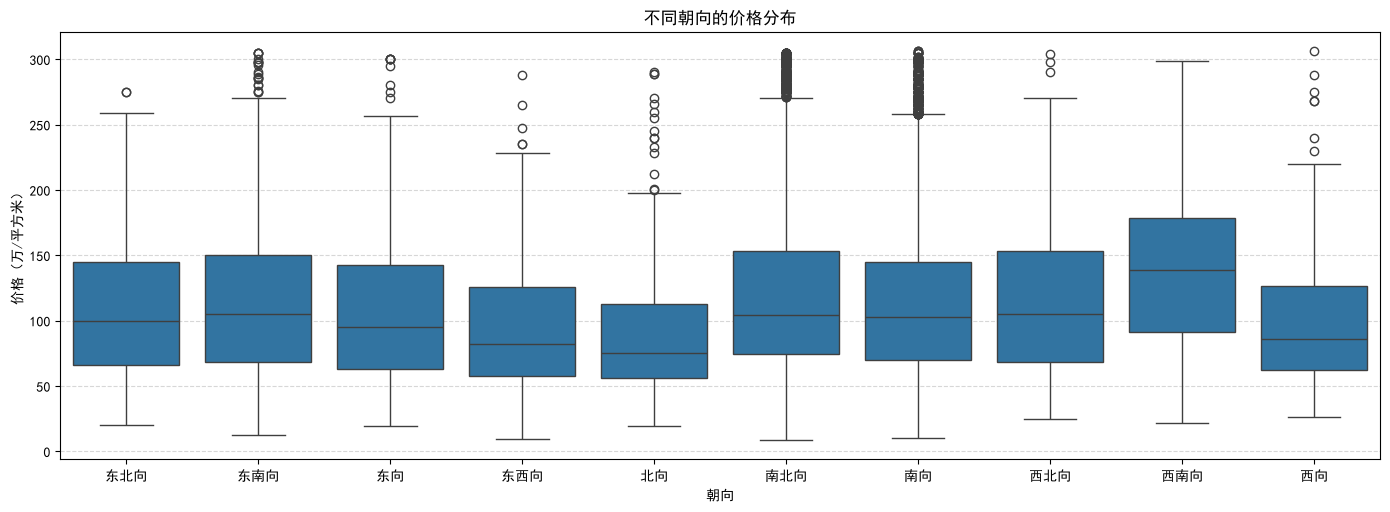

In [121]:
# 数据可视化
plt.figure(figsize=(14,5))
sns.boxplot(x='toward',y='price',data=df)
plt.tight_layout()
plt.xlabel('朝向')
plt.ylabel('价格（万/平方米）')
plt.title('不同朝向的价格分布')
plt.grid(axis='y',alpha=0.5,linestyle='--')
plt.show()